In [ ]:
import pybamm
import numpy as np

from DFN import DFN
from DC1 import DC1

params = pybamm.ParameterValues({
    # Geometry
    "L_sep": 12e-6,
    "L_anode": 85.2e-6,
    "L_cathode": 75.6e-6,

    # Butler-Folmer anode, negative (C)
    "Fk_anode": 6.48e-7,
    "C_max_anode": 33133,
    "U_anode": lambda x: (
        1.9793 * pybamm.exp(-39.3631 * x) + 0.2482
        - 0.0909 * pybamm.tanh(29.8538 * (x - 0.1234))
        - 0.04478 * pybamm.tanh(14.9159 * (x - 0.2769))
        - 0.0205 * pybamm.tanh(30.4444 * (x - 0.6103))
    ),

    # Butler-Folmer cathode, positive (NMC)
    "Fk_cathode": 3.42e-6,
    "C_max_cathode": 63104,
    "U_cathode": lambda x: (
        -0.8090 * x + 4.4875
        - 0.0428 * pybamm.tanh(18.5138 * (x - 0.5542))
        - 17.7326 * pybamm.tanh(15.7890 * (x - 0.3117))
        + 17.5842 * pybamm.tanh(15.9308 * (x - 0.3120))
    ),

    # Electrolyte
    "D_e": lambda c: 8.794e-11 * (c/1000) ** 2 - 3.972e-10 * (c/1000) + 4.862e-10,
    "kappa_e": lambda c: 0.1297 * (c/1000) ** 3 - 2.51 * (c/1000) ** 1.5 + 3.329 * (c/1000),
    "t_plus": 0.2594,
    "eps_sep": 0.47,
    "tau_sep": 0.47 / 0.47**1.5,
    "tau_anode": 0.25 / 0.25**1.5,
    "tau_cathode": 0.335 / 0.335**1.5,

    # Solid anode
    "eps_s_anode": 0.75,
    "kappa_s_anode": 215,
    "D_s_anode": 3.3e-14,
    "R_p_anode": 5.86e-6,

    # Solid cathode
    "eps_s_cathode": 0.665,
    "kappa_s_cathode": 0.18,
    "D_s_cathode": 4e-15,
    "R_p_cathode": 5.22e-6,

    # General
    "T": 298.15,

    # Initial
    "C_e_0": 1000,
    "C_s_0_anode": 0.9014 * 33133,
    "C_s_0_cathode": 0.27 * 63104,
    
    # Cutoff
    "u_min" : 2.5,
    "u_max" : 4.4
})

t_eval = np.linspace(0, 4000, 20001)

In [7]:
dc1 = DC1()
dfn = DFN()

dfn1C = dfn.run(pybamm.ParameterValues({**params, "I": lambda t: 1 * 5 / 0.1027}), 60, 60, t_eval)
dc1C = dc1.run(pybamm.ParameterValues({**params, "I": lambda t: 1 * 5 / 0.1027}), 60, t_eval)

t_end_dfn_1C = dfn1C.t[-1] - 1
t_end_dc1_1C = dc1C.t[-1] - 1

dfn1C = dfn.run(pybamm.ParameterValues({**params, "I": lambda t: 1 * 5 / 0.1027 * (t < t_end_dfn_1C)}), 60, 60, t_eval)
dc1C = dc1.run(pybamm.ParameterValues({**params, "I": lambda t: 1 * 5 / 0.1027 * (t < t_end_dc1_1C)}), 60, t_eval)

# dfn15C = dfn.run(pybamm.ParameterValues({**params, "I": lambda t: 1.5 * 5 / 0.1027}), 60, 60, t_eval)
# dc15C = dc1.run(pybamm.ParameterValues({**params, "I": lambda t: 1.5 * 5 / 0.1027}), 60, t_eval)

# t_end_dfn_15C = dfn15C.t[-1] - 1
# t_end_dc1_15C = dc15C.t[-1] - 1

# dfn15C = dfn.run(pybamm.ParameterValues({**params, "I": lambda t: 1.5 * 5 / 0.1027 * (t < t_end_dfn_15C)}), 60, 60, t_eval)
# dc15C = dc1.run(pybamm.ParameterValues({**params, "I": lambda t: 1.5 * 5 / 0.1027 * (t < t_end_dc1_15C)}), 60, t_eval)

# dfn05C = dfn.run(pybamm.ParameterValues({**params, "I": lambda t: 0.5 * 5 / 0.1027}), 60, 60, t_eval)
# dc105C = dc1.run(pybamm.ParameterValues({**params, "I": lambda t: 0.5 * 5 / 0.1027}), 60, t_eval)

# t_end_dfn_05C = dfn05C.t[-1] - 1
# t_end_dc1_05C = dc105C.t[-1] - 1

# dfn05C = dfn.run(pybamm.ParameterValues({**params, "I": lambda t: 0.5 * 5 / 0.1027 * (t < t_end_dfn_05C)}), 60, 60, t_eval)
# dc105C = dc1.run(pybamm.ParameterValues({**params, "I": lambda t: 0.5 * 5 / 0.1027 * (t < t_end_dc1_05C)}), 60, t_eval)

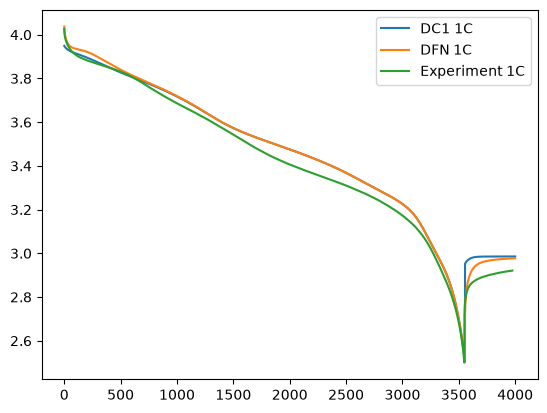

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

data_exp = pd.read_csv("LGM50_cell02.csv")
data1C = data_exp[data_exp["Step"] >= 17][data_exp["Step"] <= 18]
data1C["Test Time [s]"] = data1C["Test Time [s]"] - data1C["Test Time [s]"].iloc[0]
data1C = data1C[data1C["Test Time [s]"] <= 4000]

plt.plot(dc1C.t, dc1C["voltage"].data, label="DC1 1C")
plt.plot(dfn1C.t, dfn1C["voltage"].data, label="DFN 1C")
plt.plot(data1C["Test Time [s]"], data1C["Voltage [V]"], label="Experiment 1C")

plt.legend()